# Analyse du corpus annoté

Exploration only (voir README : les notebooks ne sont pas load-bearing). Fusionne les offres annotées manuellement (`data/annotations/`) avec leur texte source (`data/interim/`), puis analyse la distribution des labels sur les 100 premières annonces annotées.

## 1. Chargement et fusion des données

Jointure entre le texte source (`unannotated_data.csv`) et les labels (`annotations_offres_1-100.csv`) sur `offer_id`.

In [1]:
import pandas as pd

unannotated_df = pd.read_csv(r"..\data\interim\unannotated_data.csv")
unannotated_df = unannotated_df[["offer_id", "intitule", "description"]]
unannotated_df.head()

C:\Users\ELITEBOOK\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


,offer_id,intitule,description
0,213RSLS,Développeur Full stack .NET/ Angular Confirmé ...,Rejoignez VISEO et découvrez un monde de possi...
1,213RSKC,Développeur JAVA/REACT (H/F),Rejoignez VISEO et découvrez un monde de possi...
2,213RSHY,Développeur Full stack .NET/ React Confirmé (H/F),Rejoignez VISEO et découvrez un monde de possi...
3,213RSGZ,Développeur Java Angular (H/F),"Dans le cadre du renforcement de leur équipe, ..."
4,213RQSL,Développeur / Développeuse CRM Salesforce (H/F),Nous recherchons un(e) Développeur Salesforce ...


In [2]:
annotations = pd.read_csv(r"..\data\annotations\annotations_offres_1-100.csv")
annotations.drop(columns=["sheet_row"], inplace=True)

In [13]:
annotated_df = unannotated_df.merge(
    annotations, 
    how="right", 
    on="offer_id",
    validate="1:1"
    )
annotated_df["contract_type"] = annotated_df["contract_type"].fillna("cdi")
annotated_df.drop(columns=["exclude","notes"], inplace=True)
annotated_df.head()

,offer_id,intitule,description,seniority,contract_type,home_office_policy,min_salary,max_salary,salary_period,skills
0,213RSLS,Développeur Full stack .NET/ Angular Confirmé ...,Rejoignez VISEO et découvrez un monde de possi...,confirme,cdi,on_site,NaN,NaN,NaN,".net, angular, azure, react"
1,213RSKC,Développeur JAVA/REACT (H/F),Rejoignez VISEO et découvrez un monde de possi...,confirme,cdi,hybrid,NaN,NaN,NaN,"java, react, typescript, jest, testing library..."
2,213RSHY,Développeur Full stack .NET/ React Confirmé (H/F),Rejoignez VISEO et découvrez un monde de possi...,confirme,cdi,on_site,NaN,NaN,NaN,".net, react, azure"
3,213RSGZ,Développeur Java Angular (H/F),"Dans le cadre du renforcement de leur équipe, ...",confirme,cdi,on_site,NaN,NaN,NaN,"java, spring, spring boot, spring batch, sprin..."
4,213RQSL,Développeur / Développeuse CRM Salesforce (H/F),Nous recherchons un(e) Développeur Salesforce ...,confirme,cdi,on_site,NaN,NaN,NaN,"salesforce, apex, lightning web components, so..."


> **Hypothèse à noter :** les `contract_type` manquants sont remplis par défaut à `"cdi"` (le cas le plus fréquent). C'est une simplification pratique, pas une vérité observée — à documenter dans `docs/annotation-guide.md` si elle est gardée pour la suite.

In [ ]:
# annotated_df.to_csv(r"..\data\interim\annotated_data.csv", index=False)

## 2. Aperçu général du dataset fusionné

In [5]:
df = pd.read_csv(r"..\data\interim\annotated_data.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   offer_id            100 non-null    object 
 1   intitule            100 non-null    object 
 2   description         100 non-null    object 
 3   seniority           99 non-null     object 
 4   contract_type       100 non-null    object 
 5   home_office_policy  99 non-null     object 
 6   min_salary          27 non-null     float64
 7   max_salary          21 non-null     float64
 8   salary_period       27 non-null     object 
 9   skills              87 non-null     object 
 10  exclude             1 non-null      object 
 11  notes               100 non-null    object 
dtypes: float64(2), object(10)
memory usage: 9.5+ KB


## 3. Analyse des labels

Distribution de chaque champ du schéma `JobPosting`, pour repérer les déséquilibres de classes et la qualité de l'annotation avant de passer à la modélisation (Milestone 2).

In [6]:
import matplotlib.pyplot as plt
from collections import Counter

BLUE = "#2a78d6"

### 3.1 Séniorité (`seniority`)

seniority
confirme    76
senior       8
junior       8
lead         6
manager      1
NaN          1
Name: count, dtype: int64


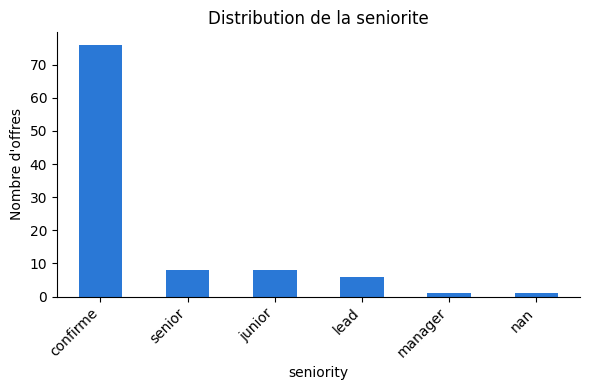

In [7]:
seniority_counts = df["seniority"].value_counts(dropna=False)
print(seniority_counts)

fig, ax = plt.subplots(figsize=(6, 4))
seniority_counts.plot(kind="bar", color=BLUE, ax=ax)
ax.set_ylabel("Nombre d'offres")
ax.set_title("Distribution de la seniorite")
ax.spines[["top", "right"]].set_visible(False)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

### 3.2 Type de contrat (`contract_type`)

contract_type
cdi           99
alternance     1
Name: count, dtype: int64


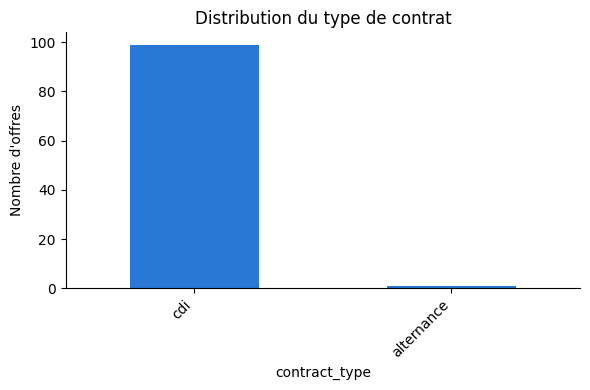

In [8]:
contract_counts = df["contract_type"].value_counts(dropna=False)
print(contract_counts)

fig, ax = plt.subplots(figsize=(6, 4))
contract_counts.plot(kind="bar", color=BLUE, ax=ax)
ax.set_ylabel("Nombre d'offres")
ax.set_title("Distribution du type de contrat")
ax.spines[["top", "right"]].set_visible(False)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

### 3.3 Politique de télétravail (`home_office_policy`)

home_office_policy
on_site    83
hybrid     16
NaN         1
Name: count, dtype: int64


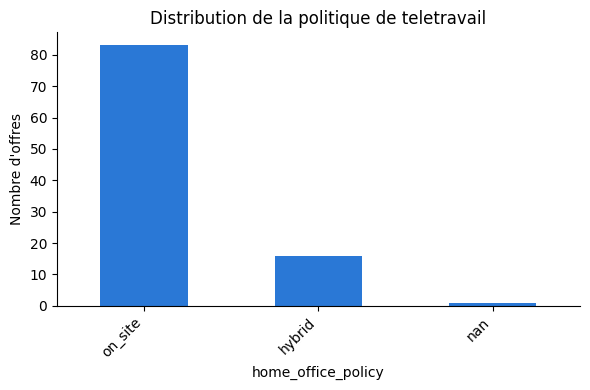

In [9]:
home_office_counts = df["home_office_policy"].value_counts(dropna=False)
print(home_office_counts)

fig, ax = plt.subplots(figsize=(6, 4))
home_office_counts.plot(kind="bar", color=BLUE, ax=ax)
ax.set_ylabel("Nombre d'offres")
ax.set_title("Distribution de la politique de teletravail")
ax.spines[["top", "right"]].set_visible(False)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

### 3.4 Salaire (`salary_range`)

Le salaire est rarement mentionné — on regarde d'abord le taux de présence, puis on sépare `annual` et `daily` (freelance) avant de tracer quoi que ce soit : mélanger les deux échelles (~40 000€/an vs ~400€/jour) sur un même graphique n'aurait pas de sens.

In [10]:
has_salary = df["min_salary"].notna()
print(f"Offres avec salaire renseigne : {has_salary.sum()} / {len(df)} ({has_salary.mean():.0%})")
print()
print("Repartition par periode :")
print(df["salary_period"].value_counts(dropna=False))

Offres avec salaire renseigne : 27 / 100 (27%)

Repartition par periode :
salary_period
NaN       73
annual    27
Name: count, dtype: int64


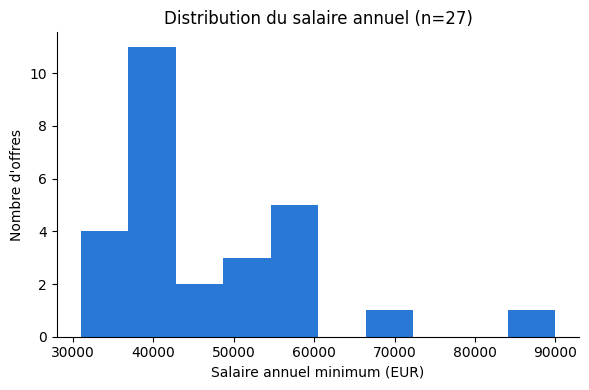

TJM (freelance) releves : []


In [11]:
annual_salaries = df.loc[df["salary_period"] == "annual", "min_salary"]

if len(annual_salaries) > 0:
    fig, ax = plt.subplots(figsize=(6, 4))
    annual_salaries.plot(kind="hist", bins=10, color=BLUE, ax=ax)
    ax.set_xlabel("Salaire annuel minimum (EUR)")
    ax.set_ylabel("Nombre d'offres")
    ax.set_title(f"Distribution du salaire annuel (n={len(annual_salaries)})")
    ax.spines[["top", "right"]].set_visible(False)
    plt.tight_layout()
    plt.show()
else:
    print("Pas assez d'offres avec salaire annuel pour un histogramme.")

daily_salaries = df.loc[df["salary_period"] == "daily", "min_salary"]
print(f"TJM (freelance) releves : {sorted(daily_salaries.tolist())}")

### 3.5 Compétences (`skills`)

Stockées comme une chaîne séparée par des virgules dans le CSV — on la reparse en liste avant d'analyser.

In [12]:
def parse_skills(cell: object) -> list[str]:
    if pd.isna(cell):
        return []
    return [s.strip() for s in str(cell).split(",") if s.strip()]

skills_lists = df["skills"].apply(parse_skills)
n_skills_per_offer = skills_lists.apply(len)

print(f"Offres sans aucune competence listee : {(n_skills_per_offer == 0).sum()} / {len(df)}")
non_empty = n_skills_per_offer[n_skills_per_offer > 0]
print(f"Nombre moyen de competences par offre (hors offres vides) : {non_empty.mean():.1f}")

all_skills = Counter(skill for skills in skills_lists for skill in skills)
print(f"Competences uniques dans le corpus : {len(all_skills)}")

Offres sans aucune competence listee : 13 / 100
Nombre moyen de competences par offre (hors offres vides) : 9.3
Competences uniques dans le corpus : 228


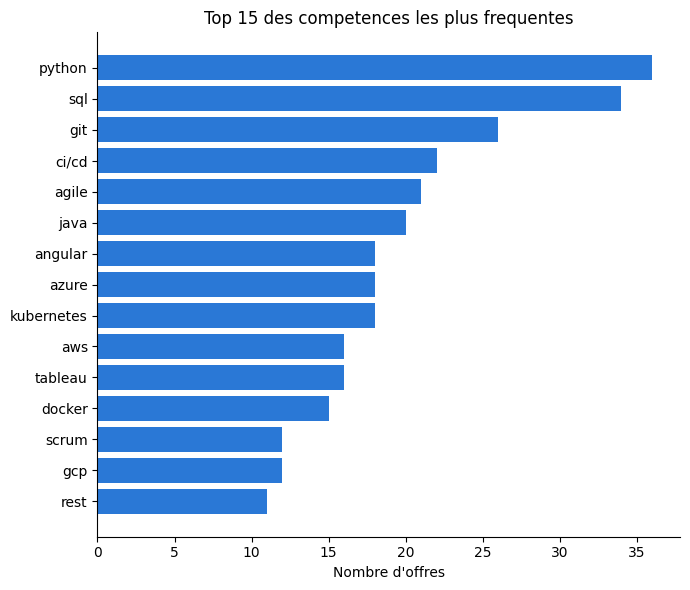

In [13]:
top_skills = all_skills.most_common(15)
labels = [s for s, _ in top_skills][::-1]
counts = [c for _, c in top_skills][::-1]

fig, ax = plt.subplots(figsize=(7, 6))
ax.barh(labels, counts, color=BLUE)
ax.set_xlabel("Nombre d'offres")
ax.set_title("Top 15 des competences les plus frequentes")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

### 3.6 Qualité des annotations

Valeurs manquantes sur les champs obligatoires du schéma, et annonces marquées `exclude`.

In [14]:
missing_summary = df[["seniority", "contract_type", "home_office_policy", "skills"]].isna().sum()
print("Valeurs manquantes par champ :")
print(missing_summary)
print()

excluded = df["exclude"].notna()
print(f"Offres marquees 'exclude' : {excluded.sum()} / {len(df)}")
if excluded.any():
    print(df.loc[excluded, ["offer_id", "exclude", "notes"]].to_string(index=False))

Valeurs manquantes par champ :
seniority              1
contract_type          0
home_office_policy     1
skills                13
dtype: int64

Offres marquees 'exclude' : 1 / 100
offer_id                                                   exclude                                                                                                                                                                                          notes
 213RKYD EXCLUDE - type de contrat non supporte (probable interim) employeur = FMS Inclusive Interim, Entreprise Adaptee de Travail Temporaire -> typeContrat probablement MIS ; ligne non annotee, a confirmer sur le champ structure avant exclusion definitive


## Conclusion

Chiffres à surveiller pour la suite (Milestone 2) :
- Déséquilibre de classes par champ (voir 3.1-3.3) — influence le choix des métriques (F1 macro plutôt qu'accuracy si une classe domine)
- Salaire renseigné sur une minorité d'offres seulement — `salary_range` restera un champ à `null` fréquent, pas un défaut du modèle
- Compétences absentes sur certaines offres — vérifier si c'est une vraie absence dans le texte ou un oubli d'annotation
- Toute ligne `exclude` doit être retirée avant l'entraînement, pas juste signalée